In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

In [2]:
###-----------------
### Import Libraries
###-----------------
import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix

In [3]:
###-----------------
### Global Variables
###-----------------
# inpDir = os.path.join('..', '..', 'input')
# outDir = '../output'
# modelDir = '../models'
# subDir = 'fashion_mnist'
# altName = 'A04_fashion_vanila'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible results
tf.random.set_seed(RANDOM_STATE)

# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 5),
          'axes.labelsize': 'large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large'
         }

CMAP = 'brg' # plt.cm.Spectral

plt.rcParams.update(params)


In [4]:
altName = 'vanilla'

###-----------------
### Hyper Parameters
###-----------------


EPOCHS = 100 # number of epochs
ALPHA = 0.001 # learning rate
BATCH_SIZE = 16 # mini batch size (number of rows)
TRAIN_SIZE = int(18 * BATCH_SIZE)
TEST_SIZE = 0.2
WEIGHT_DECAY = 0.001
PATIENCE = 20
LR_FACTOR = 0.1
LR_PATIENCE = 5
MIN_LR = 1e-6

## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [5]:
train_filename = '../input/fashion_mnist/fashion-mnist_train.csv'
test_filename = '../input/fashion_mnist/fashion-mnist_test.csv'

train_df = pd.read_csv(train_filename, header = 0)
test_df = pd.read_csv(test_filename, header = 0)

train_df.shape, test_df.shape

((60000, 785), (10000, 785))

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [6]:
# labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
              'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# mapping labels to numeric labels
class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [7]:
def fn_plot_label(tr_df, ts_df):
    plt.figure()
    plt.subplot(1,2,1)
    ax = tr_df['label'].value_counts().plot(kind='bar', title='Train', color='DarkBlue', alpha=0.7)
    plt.subplot(1,2,2)
    ax = ts_df['label'].value_counts().plot(kind='bar', title='Test', color='Orange', alpha=0.7)
    

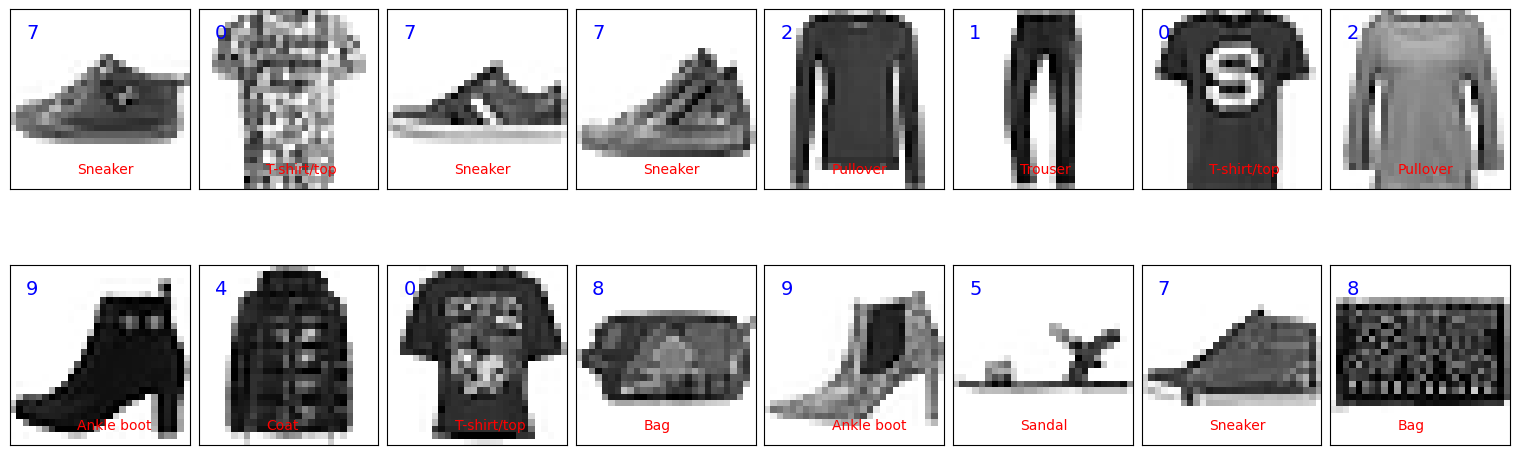

In [8]:
plot_df = train_df.sample(n=BATCH_SIZE)
fig = plt.figure()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

i=0
for _, row in plot_df.iterrows():
    i = i + 1
    image = row.values[1:].reshape(28,28)
    ax = fig.add_subplot(BATCH_SIZE//8, 8, (i), xticks=[], yticks=[])
    ax.imshow(image, cmap=plt.cm.binary, interpolation='nearest')
    ax.text(2,4, str(row.iloc[0]), color='b', fontsize=14)
    ax.text(10,25, class_names[row.iloc[0]], color='r', fontsize=10)
plt.show()

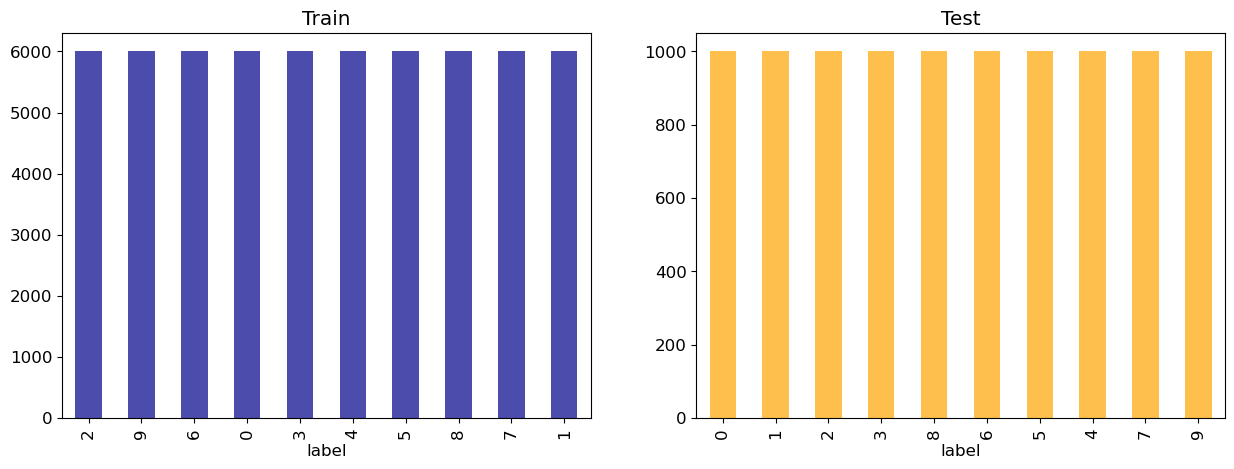

In [9]:
fn_plot_label(train_df, test_df)

Balanced data

In [10]:
def split_feature_label(row):
    feature = tf.reshape(row[1:], [28, 28, 1])
    label = row[0]
    return feature, label


In [11]:
tmp_ds = tf.data.Dataset.from_tensor_slices(train_df)
train_ds = tmp_ds.map(split_feature_label)
train_ds = train_ds.batch(batch_size=BATCH_SIZE)
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

tmp_ds = tf.data.Dataset.from_tensor_slices(test_df)
test_ds = tmp_ds.map(split_feature_label)
test_ds = test_ds.batch(batch_size=BATCH_SIZE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [12]:
# fig = plt.figure()
# fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# i=0
# for images, labels in train_ds.take(1):
#     for i in range(BATCH_SIZE):
#         ax = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[])
#         ax.grid(False)
#         ax.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary, interpolation='nearest')
#         ax.text(2,4, str(labels[i].numpy()), color='b', fontsize=14)
#         ax.text(10,25, class_names[labels[i].numpy()], color='r', fontsize=10)
# plt.show()

In [13]:
# fig = plt.figure()
# fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# i=0
# for images, labels in test_ds.take(1):
#     for i in range(BATCH_SIZE):
#         ax = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[])
#         ax.grid(False)
#         ax.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary, interpolation='nearest')
#         ax.text(2,4, str(labels[i].numpy()), color='b', fontsize=14)
#         ax.text(10,25, class_names[labels[i].numpy()], color='r', fontsize=10)
# plt.show()

Rescaling

In [14]:
# norm_layer = tf.keras.layers.Rescaling(1.0/255)

# print(f'Pre norm - MinMax: {images[0].numpy().min()}, {images[0].numpy().max()}')

# norm_ds = train_ds.map(lambda x, y: (norm_layer(x), y))
# images, labels = next(iter(norm_ds))
# print(f'Post norm - MinMax: {images[0].numpy().min()}, {images[0].numpy().max()}')

### conv in action

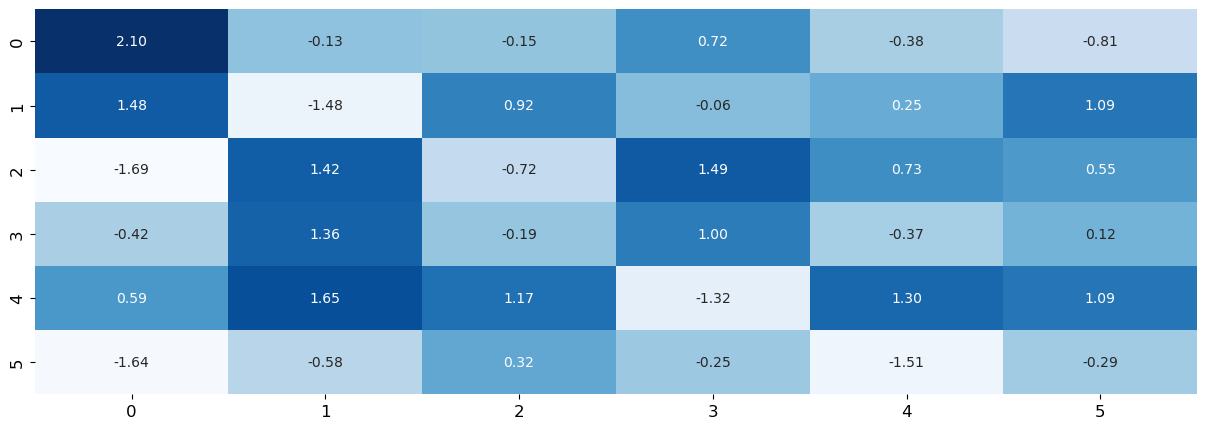

In [15]:
input_shape = (1, 6, 6, 1) # batch, 6,6 image, 1 channel
X = tf.random.normal(input_shape)
sns.heatmap(X.numpy()[0, :, :, 0], annot=True, fmt='.2f', cbar=False, cmap='Blues');

In [16]:
y = tf.keras.layers.Conv2D(1, 3, kernel_initializer=tf.constant_initializer(1.0), use_bias=False, activation='relu')(X)

y.shape

TensorShape([1, 4, 4, 1])

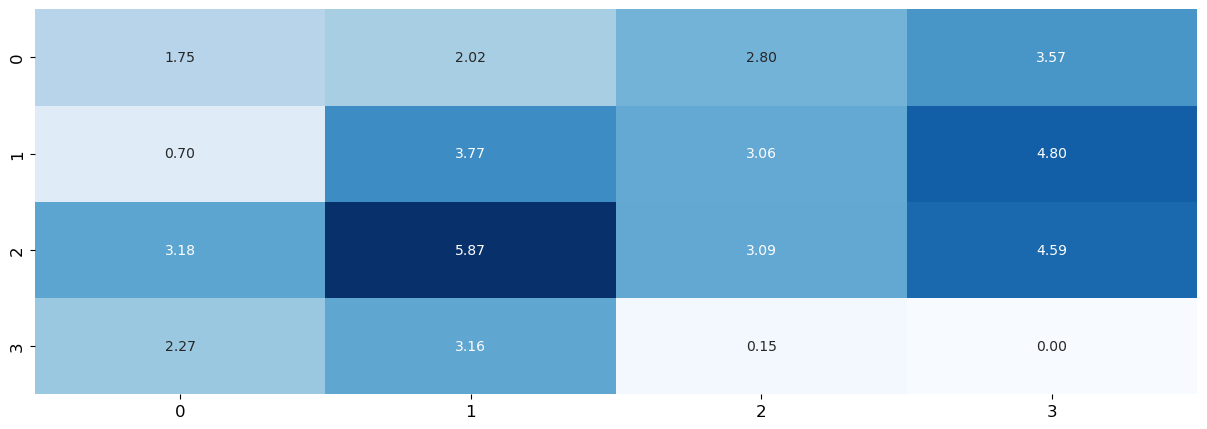

In [17]:
sns.heatmap(y.numpy()[0, :, :, 0], annot=True, fmt='.2f', cbar=False, cmap='Blues');

In [18]:
max_pool_2d = tf.keras.layers.MaxPool2D()(y)
max_pool_2d.shape

TensorShape([1, 2, 2, 1])

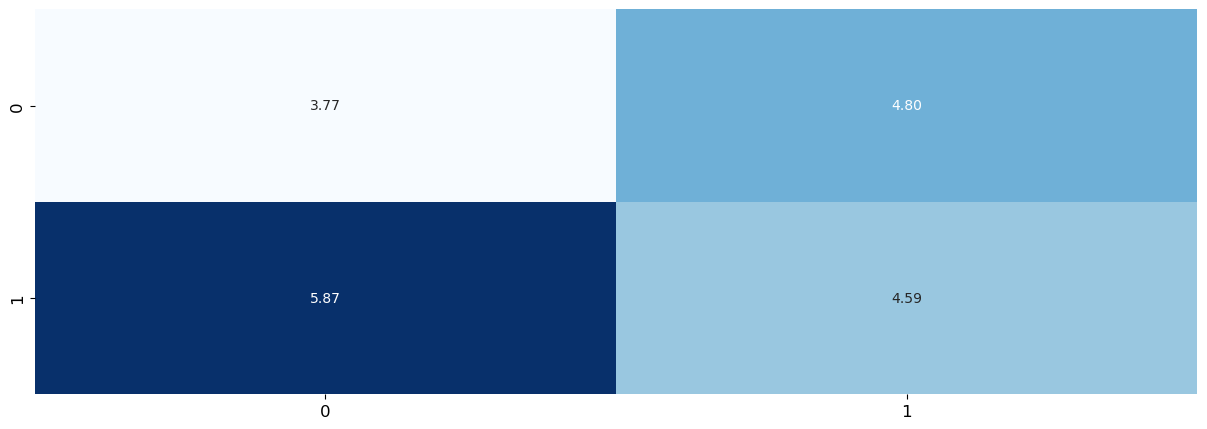

In [19]:
sns.heatmap(max_pool_2d.numpy()[0, :, :, 0], annot=True, fmt='.2f', cbar=False, cmap='Blues');

In [20]:
# checking for missing values
train_df.isna().sum().sum(), test_df.isna().sum().sum()

(np.int64(0), np.int64(0))

# YHA SE NEW H

In [25]:
input_shape = (28, 28, 1)

regularizer = tf.keras.regularizers.L2(l2=0.001)

dor1 = 0.3
dor2 = 0.3
dor3 = 0.3
dor4 = 0.3

model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=input_shape))
model.add(tf.keras.layers.Rescaling(1.0/255))

# Dropout before maxpool is mild, after maxpool is string
# we need string sometmes for paracity

# set 1
model.add(tf.keras.layers.Conv2D(32, (3,3), padding='same')) # 28, 28, 32
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D()) # 14, 14, 32
model.add(tf.keras.layers.Dropout(dor1))

# set 2
model.add(tf.keras.layers.Conv2D(64, (3,3))) # 6 X 6 X 64
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D()) 
model.add(tf.keras.layers.Dropout(dor2))

# set 3
model.add(tf.keras.layers.Conv2D(128, (3,3))) # 4, 4, 128
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.Dropout(dor3))
model.add(tf.keras.layers.Flatten())

# head
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10))

In [26]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) # loss function
optimizer = tf.keras.optimizers.AdamW(learning_rate=ALPHA)   # optimizer
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy']) # model compilation

In [27]:
# CALLBACKS


# Stops training early if validation loss stops improving to prevent overfitting
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    verbose=1,
    restore_best_weights=True  # Fixed typo: restore_best_weight -> restore_best_weights
)


# Reduces learning rate when validation loss plateaus to help convergence
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(  # Fixed variable name conflict
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_lr=MIN_LR,
)

In [28]:
history = model.fit(train_ds, validation_data=test_ds, 
                    epochs=EPOCHS, callbacks=[reduce_lr_callback, es_callback])


Epoch 1/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 67s 17ms/step - accuracy: 0.8250 - loss: 0.4751 - val_accuracy: 0.8889 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 2/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step - accuracy: 0.8739 - loss: 0.3425 - val_accuracy: 0.8946 - val_loss: 0.2858 - learning_rate: 0.0010
Epoch 3/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 64s 17ms/step - accuracy: 0.8902 - loss: 0.2998 - val_accuracy: 0.9021 - val_loss: 0.2711 - learning_rate: 0.0010
Epoch 4/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step - accuracy: 0.8958 - loss: 0.2782 - val_accuracy: 0.8734 - val_loss: 0.3322 - learning_rate: 0.0010
Epoch 5/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step - accuracy: 0.9025 - loss: 0.2624 - val_accuracy: 0.9047 - val_loss: 0.2596 - learning_rate: 0.0010
Epoch 6/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step - accuracy: 0.9068 - loss: 0.2510 - val_accuracy: 0.9041 - val_loss: 0.2642 - learning_rate: 0.0010
Epoch 7/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 63s 17ms/step -

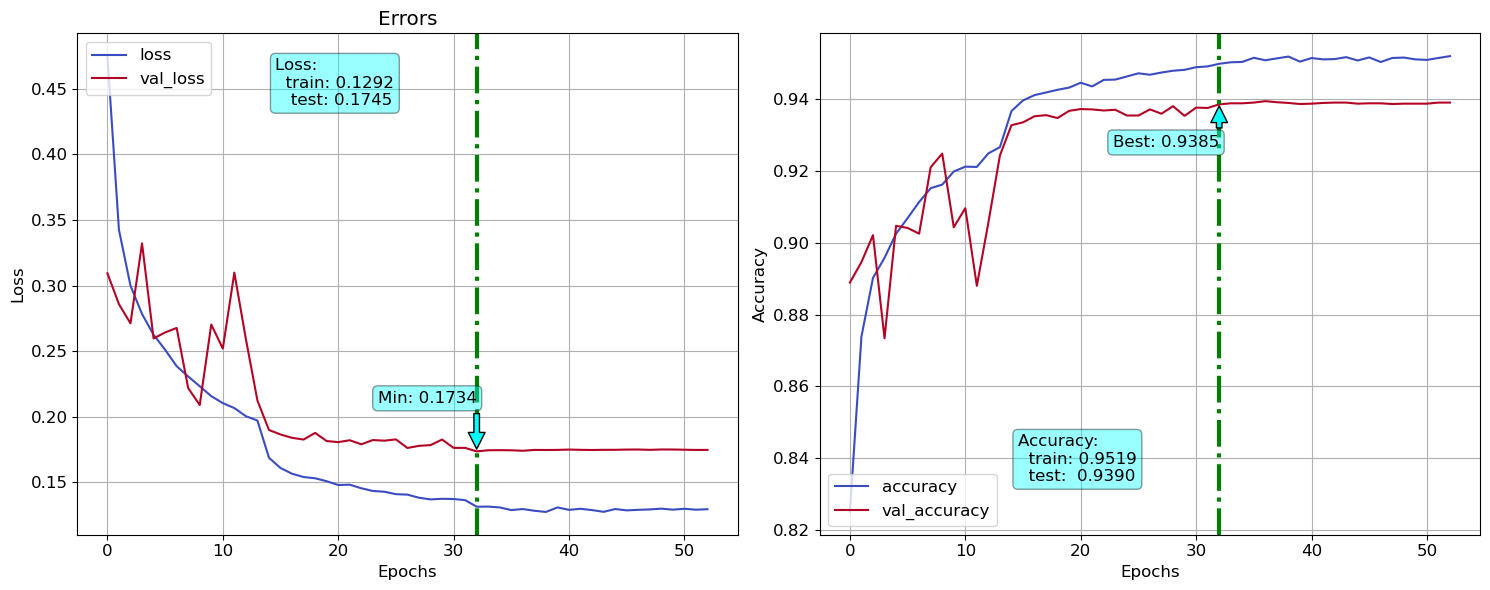

In [29]:
hist_df = pd.DataFrame(history.history)
fn_plot_tf_hist(hist_df)

### Train pred

In [ ]:
y_train = tf.concat([y for x, y in train_ds], axis=0).numpy()
print(y_train.shape)

(60000,)


In [ ]:
yhat = model.predict(train_ds)
y_pred = yhat.argmax(axis=1)
print(f'Accuracy: {accuracy_score(y_train, y_pred):.5f}')
print(classification_report(y_train, y_pred))

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step
Accuracy: 0.92673
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      6000
           1       1.00      0.98      0.99      6000
           2       0.91      0.87      0.89      6000
           3       0.90      0.95      0.93      6000
           4       0.88      0.85      0.87      6000
           5       1.00      0.98      0.99      6000
           6       0.75      0.85      0.80      6000
           7       0.97      0.97      0.97      6000
           8       0.99      0.99      0.99      6000
           9       0.96      0.99      0.97      6000

    accuracy                           0.93     60000
   macro avg       0.93      0.93      0.93     60000
weighted avg       0.93      0.93      0.93     60000



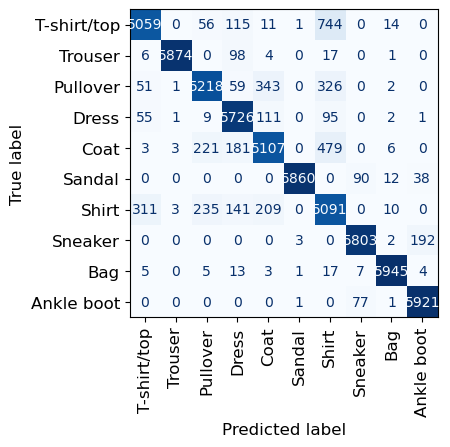

In [ ]:
fn_plot_confusion_matrix(y_train, y_pred, class_names)

### Test pred

In [ ]:
y_test = tf.concat([y for x, y in test_ds], axis=0).numpy()
print(y_test.shape)

(10000,)


In [ ]:
yhat = model.predict(test_ds)
y_pred = yhat.argmax(axis=1)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.5f}')
print(classification_report(y_test, y_pred))

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Accuracy: 0.91400
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      1000
           1       1.00      0.98      0.99      1000
           2       0.90      0.85      0.87      1000
           3       0.89      0.95      0.92      1000
           4       0.88      0.85      0.87      1000
           5       0.99      0.96      0.98      1000
           6       0.73      0.81      0.77      1000
           7       0.95      0.96      0.95      1000
           8       0.98      0.98      0.98      1000
           9       0.95      0.98      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



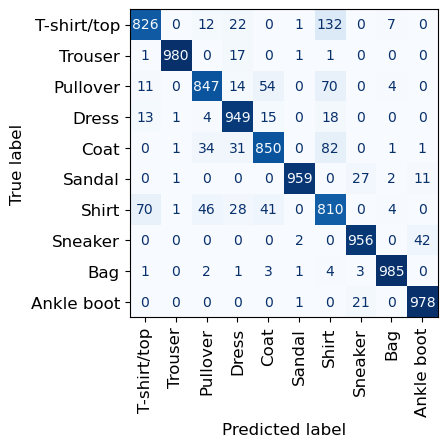

In [ ]:
fn_plot_confusion_matrix(y_test, y_pred, class_names)

model(images)

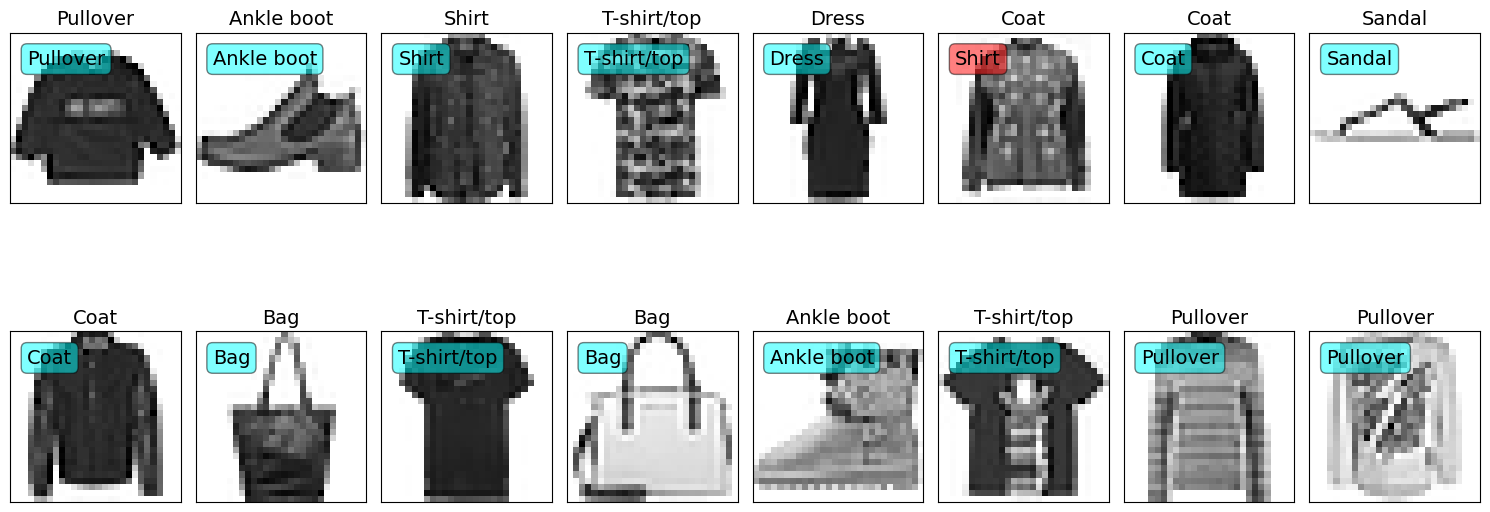

In [ ]:
fig = plt.figure(figsize=(15, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

i=0
for images, labels in train_ds.take(1):
    yhat = model(images).numpy()
    y_pred = yhat.argmax(axis=1)

    for i in range(BATCH_SIZE):
        ax = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[])
        ax.grid(False)
        color = 'cyan'
        if y_pred[i] != labels[i]:
            color='red'
        props = dict(boxstyle='round', facecolor=color, alpha=0.5)
        ax.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary)

        ax.text(0.1, 0.90, class_names[y_pred[i]] , bbox=props,
                verticalalignment='top',
                transform=ax.transAxes, fontsize=14)
        
        ax.set_title(class_names[labels[i].numpy()], fontsize=14)
plt.tight_layout()
plt.show()